In [1]:
import numpy as np
import openmc
import openmc.stats
import matplotlib.pyplot as plt

In [2]:
###############################################################################
#                           1. MATERIALS
###############################################################################

# ── Conversion factor ──
INCHES = 2.54  # cm per inch

# ── UO2 Fuel — 1.6 % enrichment ──
uo2_16 = openmc.Material(name='UO2 1.6%')
uo2_16.set_density('g/cm3', 10.257)
uo2_16.add_nuclide('U235', 0.016, 'wo')
uo2_16.add_nuclide('U238', 0.8724, 'wo')
uo2_16.add_nuclide('O16',  0.1116, 'wo')
uo2_16.temperature = 900.0  # K (fuel centerline avg)

# ── UO2 Fuel — 2.4 % enrichment ──
uo2_24 = openmc.Material(name='UO2 2.4%')
uo2_24.set_density('g/cm3', 10.257)
uo2_24.add_nuclide('U235', 0.024, 'wo')
uo2_24.add_nuclide('U238', 0.8644, 'wo')
uo2_24.add_nuclide('O16',  0.1116, 'wo')
uo2_24.temperature = 900.0

# ── UO2 Fuel — 3.1 % enrichment ──
uo2_31 = openmc.Material(name='UO2 3.1%')
uo2_31.set_density('g/cm3', 10.257)
uo2_31.add_nuclide('U235', 0.031, 'wo')
uo2_31.add_nuclide('U238', 0.8574, 'wo')
uo2_31.add_nuclide('O16',  0.1116, 'wo')
uo2_31.temperature = 900.0

gd_fuel = openmc.Material(name='UO2-Gd2O3')
gd_fuel.set_density('g/cm3', 10.2)
# Uranium (slightly reduced enrichment)
gd_fuel.add_nuclide('U235', 0.028, 'wo')
gd_fuel.add_nuclide('U238', 0.85,  'wo')
# Gadolinium isotopes (dominant absorbers)
gd_fuel.add_nuclide('Gd155', 0.01, 'wo')
gd_fuel.add_nuclide('Gd157', 0.01, 'wo')
# Oxygen balance
gd_fuel.add_nuclide('O16', 0.11, 'wo')
gd_fuel.temperature = 900.0

# ── Helium fill gas ──
helium = openmc.Material(name='Helium')
helium.set_density('g/cm3', 0.000178)
helium.add_element('He', 1.0)

# ── Zircaloy-4 cladding ──
zirc4 = openmc.Material(name='Zircaloy-4')
zirc4.set_density('g/cm3', 6.56)
zirc4.add_element('Zr', 0.98197, 'wo')
zirc4.add_element('Sn', 0.01450, 'wo')
zirc4.add_element('Fe', 0.00210, 'wo')
zirc4.add_element('Cr', 0.00100, 'wo')
zirc4.add_element('Hf', 0.00043, 'wo')

water = openmc.Material(name='Light Water')
water.set_density('g/cm3', 0.7405)
water.add_nuclide('H1', 2.0, 'ao')
water.add_nuclide('O16', 1.0, 'ao')
water.add_s_alpha_beta('c_H_in_H2O')
water.temperature = 557.0

# ── SS304 — stainless steel (core barrel, reflector) ──
ss304 = openmc.Material(name='SS304')
ss304.set_density('g/cm3', 8.03)
ss304.add_element('Fe', 0.695, 'wo')
ss304.add_element('Cr', 0.190, 'wo')
ss304.add_element('Ni', 0.095, 'wo')
ss304.add_element('Mn', 0.020, 'wo')

# ── Carbon steel — RPV ──
cs = openmc.Material(name='Carbon Steel RPV')
cs.set_density('g/cm3', 7.85)
cs.add_element('Fe', 0.975, 'wo')
cs.add_element('Mn', 0.015, 'wo')
cs.add_element('Si', 0.005, 'wo')
cs.add_element('Cr', 0.005, 'wo')

# ── Collect and export ──
materials = openmc.Materials([
    uo2_16, uo2_24, uo2_31, gd_fuel, helium, zirc4, water, ss304, cs
])
materials.export_to_xml()
print("✓ materials.xml exported")
print(f"  Materials defined: {[m.name for m in materials]}")

✓ materials.xml exported
  Materials defined: ['UO2 1.6%', 'UO2 2.4%', 'UO2 3.1%', 'UO2-Gd2O3', 'Helium', 'Zircaloy-4', 'Light Water', 'SS304', 'Carbon Steel RPV']


In [3]:
###############################################################################
#                       2. GEOMETRY — DIMENSIONS
###############################################################################
# Source: NuScale Design Certification Application — ML17013A274, Table 4.1-2

# ── Fuel rod ──
pellet_OR   = 0.3195 * INCHES / 2   # 0.4058 cm
clad_IR     = 0.326  * INCHES / 2   # 0.4140 cm
clad_OR     = 0.374  * INCHES / 2   # 0.4750 cm

# ── Guide / instrument tube ──
gt_IR       = 0.450  * INCHES / 2   # 0.5715 cm
gt_OR       = 0.482  * INCHES / 2   # 0.6121 cm

# ── Lattice parameters ──
pin_pitch   = 0.496  * INCHES       # 1.2598 cm
assy_pitch  = 8.466  * INCHES       # 21.504 cm

# ── Axial dimensions ──
active_height = 78.74 * INCHES      # 200.00 cm
z_bot = -active_height / 2          # -100 cm
z_top =  active_height / 2          #  100 cm

# ── Radial core structures ──
core_barrel_IR = 74.0 * INCHES / 2  # 93.98 cm
core_barrel_OR = 78.0 * INCHES / 2  # 99.06 cm
rpv_IR         = 96.5 * INCHES / 2  # 122.555 cm
rpv_OR         = 105.0* INCHES / 2  # 133.35 cm

print("── Key dimensions (cm) ──")
print(f"  Pellet OR      = {pellet_OR:.4f}")
print(f"  Clad IR / OR   = {clad_IR:.4f} / {clad_OR:.4f}")
print(f"  Guide tube     = {gt_IR:.4f} / {gt_OR:.4f}")
print(f"  Pin pitch      = {pin_pitch:.4f}")
print(f"  Assembly pitch = {assy_pitch:.4f}")
print(f"  Active height  = {active_height:.2f}")
print(f"  Core barrel    = {core_barrel_IR:.2f} / {core_barrel_OR:.2f}")
print(f"  RPV            = {rpv_IR:.2f} / {rpv_OR:}")

── Key dimensions (cm) ──
  Pellet OR      = 0.4058
  Clad IR / OR   = 0.4140 / 0.4750
  Guide tube     = 0.5715 / 0.6121
  Pin pitch      = 1.2598
  Assembly pitch = 21.5036
  Active height  = 200.00
  Core barrel    = 93.98 / 99.06
  RPV            = 122.56 / 133.35


In [4]:
###############################################################################
#               2b. GEOMETRY — PIN CELL UNIVERSES (UPDATED)
###############################################################################

# ── Radial surfaces (shared by all pins) ──
s_pellet = openmc.ZCylinder(r=pellet_OR, name='Fuel pellet OR')
s_gap    = openmc.ZCylinder(r=clad_IR,   name='Clad IR / gap')
s_clad   = openmc.ZCylinder(r=clad_OR,   name='Clad OR')
s_gt_in  = openmc.ZCylinder(r=gt_IR,     name='Guide tube IR')
s_gt_out = openmc.ZCylinder(r=gt_OR,     name='Guide tube OR')


# ── Helper: create a fuel pin universe ──
def make_fuel_pin(fuel_mat, name_tag):
    """Fuel pin: fuel / gap / clad / moderator"""

    c_fuel = openmc.Cell(
        name=f'fuel {name_tag}',
        fill=fuel_mat,
        region=-s_pellet)

    c_gap = openmc.Cell(
        name=f'gap {name_tag}',
        fill=helium,
        region=+s_pellet & -s_gap)

    c_clad = openmc.Cell(
        name=f'clad {name_tag}',
        fill=zirc4,
        region=+s_gap & -s_clad)

    c_water = openmc.Cell(
        name=f'moderator {name_tag}',
        fill=water,
        region=+s_clad)

    return openmc.Universe(
        name=f'Fuel pin {name_tag}',
        cells=[c_fuel, c_gap, c_clad, c_water])


# ── Standard fuel pins ──
pin_16 = make_fuel_pin(uo2_16, '1.6%')
pin_24 = make_fuel_pin(uo2_24, '2.4%')
pin_31 = make_fuel_pin(uo2_31, '3.1%')

# ── Gadolinium fuel pin (NEW) ──
pin_gd = make_fuel_pin(gd_fuel, 'Gd')

# ── Guide tube universe (water-filled tube) ──
c_gt_water = openmc.Cell(
    name='GT inner water',
    fill=water,
    region=-s_gt_in)

c_gt_wall = openmc.Cell(
    name='GT wall',
    fill=zirc4,
    region=+s_gt_in & -s_gt_out)

c_gt_outer = openmc.Cell(
    name='GT outer water',
    fill=water,
    region=+s_gt_out)

guide_tube = openmc.Universe(
    name='Guide tube',
    cells=[c_gt_water, c_gt_wall, c_gt_outer])

print("✓ Pin-cell universes created: 1.6%, 2.4%, 3.1%, Gd, guide tube")

✓ Pin-cell universes created: 1.6%, 2.4%, 3.1%, Gd, guide tube


In [5]:
###############################################################################
#           2c. GEOMETRY — 17×17 FUEL ASSEMBLIES (FIXED + Gd)
###############################################################################

# --- Guide tube positions (unchanged) ---
gt_positions = [
    (2, 5), (2, 8), (2, 11),
    (3, 3), (3, 13),
    (5, 2), (5, 5), (5, 8), (5, 11), (5, 14),
    (8, 2), (8, 5), (8, 8), (8, 11), (8, 14),
    (11, 2), (11, 5), (11, 8), (11, 11), (11, 14),
    (13, 3), (13, 13),
    (14, 5), (14, 8), (14, 11),]

# --- NEW: Gd rod positions (SBF core) ---
gd_positions = {
    (4,4), (4,12), (12,4), (12,12),
    (3,8), (8,3), (8,13), (13,8),
    (6,6), (6,10), (10,6), (10,10)}


def make_assembly(fuel_pin, enrichment_tag):
    """Build a 17×17 fuel assembly lattice universe with Gd rods."""

    # Initialize lattice
    univs = np.empty((17, 17), dtype=openmc.Universe)

    for i in range(17):
        for j in range(17):
            if (i, j) in gt_positions:
                univs[i, j] = guide_tube
            elif (i, j) in gd_positions:
                univs[i, j] = pin_gd   # ← NEW: gadolinia pins
            else:
                univs[i, j] = fuel_pin

    # --- Lattice definition ---
    lattice = openmc.RectLattice(name=f'FA {enrichment_tag}')
    lattice.lower_left = (-17 * pin_pitch / 2, -17 * pin_pitch / 2)
    lattice.pitch = (pin_pitch, pin_pitch)
    lattice.universes = univs

    # --- IMPORTANT FIX: outer MUST be a universe ---
    water_universe = openmc.Universe(
        cells=[openmc.Cell(fill=water)])
    lattice.outer = water_universe


    # --- Assembly boundary ---
    assy_box = openmc.model.RectangularPrism(
        width=assy_pitch,
        height=assy_pitch,
        origin=(0., 0.))

    # --- Cells ---
    c_lat = openmc.Cell(
        name=f'lattice {enrichment_tag}',
        fill=lattice,
        region=-assy_box)

    c_outer = openmc.Cell(
        name=f'inter-assy water {enrichment_tag}',
        fill=water,
        region=+assy_box)

    return openmc.Universe(
        name=f'Assembly {enrichment_tag}',
        cells=[c_lat, c_outer])


# --- Build assemblies ---
assy_16 = make_assembly(pin_16, '1.6%')
assy_24 = make_assembly(pin_24, '2.4%')
assy_31 = make_assembly(pin_31, '3.1%')


# --- Water universe for core gaps ---
water_cell_univ = openmc.Universe(
    name='Water universe',
    cells=[openmc.Cell(fill=water)])

print("✓ 17×17 fuel assemblies created (SBF core with Gd)")
print(f"  Assembly pitch = {assy_pitch:.4f} cm")
print(f"  Pins: fuel + Gd + guide tubes")

✓ 17×17 fuel assemblies created (SBF core with Gd)
  Assembly pitch = 21.5036 cm
  Pins: fuel + Gd + guide tubes


In [6]:
###############################################################################
#          2d. GEOMETRY — FULL-CORE 9×9 LATTICE (FIXED)
###############################################################################

W = water_cell_univ
A = assy_16
B = assy_24
C = assy_31

# --- Core map (unchanged layout) ---
core_map = [
    [W, W, W, W, W, W, W, W, W],
    [W, W, W, C, C, C, W, W, W],
    [W, W, B, A, B, A, B, W, W],
    [W, C, A, B, A, B, A, C, W],
    [W, C, B, A, B, A, B, C, W],
    [W, C, A, B, A, B, A, C, W],
    [W, W, B, A, B, A, B, W, W],
    [W, W, W, C, C, C, W, W, W],
    [W, W, W, W, W, W, W, W, W],]

# --- Convert to NumPy array (IMPORTANT for OpenMC stability) ---
core_array = np.array(core_map, dtype=openmc.Universe)

# --- Lattice ---
core_lattice = openmc.RectLattice(name='Core lattice')

core_lattice.pitch = (assy_pitch, assy_pitch)

# IMPORTANT: lower_left must match exact width
core_width = 9 * assy_pitch
core_lattice.lower_left = (-core_width / 2, -core_width / 2)

core_lattice.universes = core_array

# --- FIX: outer MUST be a Universe ---
outer_water = openmc.Universe(
    cells=[openmc.Cell(fill=water)])
core_lattice.outer = outer_water


# --- CORE BOUNDARY (VERY IMPORTANT FIX) ---
core_box = openmc.model.RectangularPrism(
    width=core_width,
    height=core_width,
    origin=(0.0, 0.0),
    boundary_type='reflective')   # ← NO LEAKAGE (your requirement)

core_cell = openmc.Cell(
    name='Core',
    fill=core_lattice,
    region=-core_box)

root_universe = openmc.Universe(cells=[core_cell])

# --- Geometry object ---
geometry = openmc.Geometry(root_universe)

# --- Assembly count ---
n_fuel = sum(1 for row in core_map for u in row if u is not W)

print(f"✓ Core lattice: 9×9, {n_fuel} fuel assemblies")
print(f"✓ Core width: {core_width:.2f} cm (reflective boundary)")

✓ Core lattice: 9×9, 37 fuel assemblies
✓ Core width: 193.53 cm (reflective boundary)


In [7]:
###############################################################################
#     2e. GEOMETRY — CORE BARREL, DOWNCOMER, RPV & ROOT UNIVERSE (FIXED)
###############################################################################

# ── Radial surfaces ──
s_barrel_in  = openmc.ZCylinder(r=core_barrel_IR, name='Core barrel IR')
s_barrel_out = openmc.ZCylinder(r=core_barrel_OR, name='Core barrel OR')
s_rpv_in     = openmc.ZCylinder(r=rpv_IR,         name='RPV IR')

# IMPORTANT FIX: make OUTER boundary reflective (no leakage)
s_rpv_out = openmc.ZCylinder(
    r=rpv_OR,
    name='RPV OR',
    boundary_type='reflective')

# ── Axial surfaces ──
z_lower_refl = z_bot - 25.0
z_upper_refl = z_top + 25.0

# IMPORTANT FIX: reflective, not vacuum
s_zbot = openmc.ZPlane(
    z0=z_lower_refl,
    name='Bottom boundary',
    boundary_type='reflective')

s_ztop = openmc.ZPlane(
    z0=z_upper_refl,
    name='Top boundary',
    boundary_type='reflective')

s_zfbot = openmc.ZPlane(z0=z_bot, name='Fuel bottom')
s_zftop = openmc.ZPlane(z0=z_top, name='Fuel top')

# ── Cells ──
# Active core
c_core = openmc.Cell(
    name='Active core',
    fill=core_lattice,
    region=-s_barrel_in & +s_zfbot & -s_zftop)

# Lower reflector
c_lower_refl = openmc.Cell(
    name='Lower reflector',
    fill=water,
    region=-s_barrel_in & +s_zbot & -s_zfbot)

# Upper reflector
c_upper_refl = openmc.Cell(
    name='Upper reflector',
    fill=water,
    region=-s_barrel_in & +s_zftop & -s_ztop)

# Core barrel
c_barrel = openmc.Cell(
    name='Core barrel',
    fill=ss304,
    region=+s_barrel_in & -s_barrel_out & +s_zbot & -s_ztop)

# Downcomer
c_downcomer = openmc.Cell(
    name='Downcomer',
    fill=water,
    region=+s_barrel_out & -s_rpv_in & +s_zbot & -s_ztop)

# RPV steel
c_rpv = openmc.Cell(
    name='RPV',
    fill=cs,
    region=+s_rpv_in & -s_rpv_out & +s_zbot & -s_ztop)

# ── ROOT UNIVERSE ──
root = openmc.Universe(name='Root universe')
root.add_cells([
    c_core,
    c_lower_refl,
    c_upper_refl,
    c_barrel,
    c_downcomer,
    c_rpv])

# ── Geometry ──
geometry = openmc.Geometry(root)
geometry.export_to_xml()

print("✓ geometry.xml exported")
print(f"  Active core: z = [{z_bot:.1f}, {z_top:.1f}] cm")
print(f"  Full model:  z = [{z_lower_refl:.1f}, {z_upper_refl:.1f}] cm")
print(f"  Radial extent: R = {rpv_OR:.2f} cm")

✓ geometry.xml exported
  Active core: z = [-100.0, 100.0] cm
  Full model:  z = [-125.0, 125.0] cm
  Radial extent: R = 133.35 cm


In [8]:
###############################################################################
#                          3. SETTINGS (FIXED)
###############################################################################

settings = openmc.Settings()

# ── Run mode ──
settings.run_mode = 'eigenvalue'

# ── Batches & particles ──
settings.batches   = 150
settings.inactive  = 50
settings.particles = 10000


# ── Source (FIXED: fissionable only) ──
lower_left  = (-core_barrel_IR, -core_barrel_IR, z_bot)
upper_right = ( core_barrel_IR,  core_barrel_IR, z_top)

uniform_dist = openmc.stats.Box(lower_left, upper_right)

settings.source = openmc.IndependentSource(
    space=uniform_dist,
    constraints={'fissionable': True})
    
# ── Temperature treatment ──
settings.temperature = {
    'default': 557.0,
    'method': 'interpolation'}

# ── Output ──
settings.output = {'tallies': True}

settings.export_to_xml()

print("✓ settings.xml exported")
print(f"  Batches: {settings.batches} ({settings.inactive} inactive)")
print(f"  Particles/batch: {settings.particles}")
print(f"  Source box: {lower_left} → {upper_right}")

✓ settings.xml exported
  Batches: 150 (50 inactive)
  Particles/batch: 10000
  Source box: (-93.98, -93.98, -99.9998) → (93.98, 93.98, 99.9998)


In [9]:
###############################################################################
#                        4. TALLIES (FINAL CLEAN VERSION)
###############################################################################

tallies = openmc.Tallies()

# ── Energy group boundaries (eV) ──
# Thermal | Epithermal | Fast
energy_bins = [1e-5, 0.625, 1.0e5, 20.0e6]
energy_filter = openmc.EnergyFilter(energy_bins)

# ── Material filters ──
fuel_mats = [uo2_16, uo2_24, uo2_31, gd_fuel]   # ← FIXED (include Gd)
fuel_mat_filter = openmc.MaterialFilter(fuel_mats)

all_mat_filter = openmc.MaterialFilter(list(materials))  # ← FIXED

# ── Cell filters ──
cell_filter_core = openmc.CellFilter([c_core])

# ---------------------------------------------------------------------------
# TALLY 1: Energy-resolved neutron flux in fuel
# ---------------------------------------------------------------------------
t_fuel_flux = openmc.Tally(name='Fuel flux (energy-resolved)')
t_fuel_flux.filters = [fuel_mat_filter, energy_filter]
t_fuel_flux.scores  = ['flux']
tallies.append(t_fuel_flux)

# ---------------------------------------------------------------------------
# TALLY 2: Fission reaction rates
# ---------------------------------------------------------------------------
t_fission = openmc.Tally(name='Fission rates')
t_fission.filters = [fuel_mat_filter]
t_fission.scores  = ['fission', 'nu-fission', 'kappa-fission']
tallies.append(t_fission)

# ---------------------------------------------------------------------------
# TALLY 3: Energy deposition (fuel only)
# ---------------------------------------------------------------------------
t_heating = openmc.Tally(name='Fuel heating')
t_heating.filters = [fuel_mat_filter]
t_heating.scores  = ['heating']   # eV/source
tallies.append(t_heating)

# ---------------------------------------------------------------------------
# TALLY 4: Total heating (full system energy balance)
# ---------------------------------------------------------------------------
t_heat_all = openmc.Tally(name='Total heating')
t_heat_all.filters = [all_mat_filter]
t_heat_all.scores  = ['heating']
tallies.append(t_heat_all)

# ---------------------------------------------------------------------------
# TALLY 5: Absorption + scattering physics
# ---------------------------------------------------------------------------
t_abs = openmc.Tally(name='Absorption & scattering')
t_abs.filters = [fuel_mat_filter, energy_filter]
t_abs.scores  = ['absorption', 'elastic', 'scatter']
tallies.append(t_abs)

# ---------------------------------------------------------------------------
# TALLY 6: Radial mesh (XY flux + fission)
# ---------------------------------------------------------------------------
mesh_xy = openmc.RegularMesh(name='XY flux mesh')
mesh_xy.dimension = [80, 80, 1]   # reduced for speed

mesh_xy.lower_left  = [-rpv_OR, -rpv_OR, z_bot]
mesh_xy.upper_right = [ rpv_OR,  rpv_OR, z_top]

t_mesh_xy = openmc.Tally(name='Mesh flux XY')
t_mesh_xy.filters = [openmc.MeshFilter(mesh_xy)]
t_mesh_xy.scores  = ['flux', 'fission']
tallies.append(t_mesh_xy)

# ---------------------------------------------------------------------------
# TALLY 7: Axial flux profile (XZ plane)
# ---------------------------------------------------------------------------
mesh_xz = openmc.RegularMesh(name='XZ flux mesh')
mesh_xz.dimension = [80, 1, 80]

mesh_xz.lower_left  = [-rpv_OR, -1.0, z_lower_refl]
mesh_xz.upper_right = [ rpv_OR,  1.0, z_upper_refl]

t_mesh_xz = openmc.Tally(name='Mesh flux XZ')
t_mesh_xz.filters = [openmc.MeshFilter(mesh_xz)]
t_mesh_xz.scores  = ['flux']
tallies.append(t_mesh_xz)

# ---------------------------------------------------------------------------
# TALLY 8: Surface current (leakage check)
# ---------------------------------------------------------------------------
t_leakage = openmc.Tally(name='Core barrel current')
t_leakage.filters = [openmc.SurfaceFilter([s_barrel_in])]
t_leakage.scores  = ['current']
tallies.append(t_leakage)

# ---------------------------------------------------------------------------
# TALLY 9 (NEW): Core-average flux
# ---------------------------------------------------------------------------
t_core_flux = openmc.Tally(name='Core flux')
t_core_flux.filters = [cell_filter_core]
t_core_flux.scores  = ['flux']
tallies.append(t_core_flux)

# ---------------------------------------------------------------------------
# EXPORT
# ---------------------------------------------------------------------------
tallies.export_to_xml()

print(f"✓ tallies.xml exported — {len(tallies)} tallies defined")
for t in tallies:
    print(f"    • {t.name}: scores = {t.scores}")

✓ tallies.xml exported — 9 tallies defined
    • Fuel flux (energy-resolved): scores = ['flux']
    • Fission rates: scores = ['fission', 'nu-fission', 'kappa-fission']
    • Fuel heating: scores = ['heating']
    • Total heating: scores = ['heating']
    • Absorption & scattering: scores = ['absorption', 'elastic', 'scatter']
    • Mesh flux XY: scores = ['flux', 'fission']
    • Mesh flux XZ: scores = ['flux']
    • Core barrel current: scores = ['current']
    • Core flux: scores = ['flux']


In [10]:
###############################################################################
#                          5. PLOTS (FINAL FIXED)
###############################################################################

# ── Material color map ──
color_map = {
    uo2_16: (255, 80,  80),
    uo2_24: (255, 200, 50),
    uo2_31: (50,  80,  200),
    gd_fuel: (0, 180, 0),        # ← NEW: Gd pins (green)
    helium: (255, 230, 200),
    zirc4:  (180, 180, 180),
    water:  (150, 200, 255),
    ss304:  (60,  60,  60),
    cs:     (30,  30,  30),
}

plots = openmc.Plots()

# ── Plot 1: Core XY midplane ──
p_xy = openmc.Plot(name='XY core midplane')
p_xy.basis = 'xy'
p_xy.origin = (0., 0., (z_bot + z_top)/2)   # ← FIX: center of active core
p_xy.width = (2 * rpv_OR + 10, 2 * rpv_OR + 10)
p_xy.pixels = (1500, 1500)                  # slightly reduced (faster)
p_xy.color_by = 'material'
p_xy.colors = color_map
p_xy.filename = 'core_xy_midplane'
plots.append(p_xy)

# ── Plot 2: Axial slice (XZ) ──
p_xz = openmc.Plot(name='XZ axial slice')
p_xz.basis = 'xz'
p_xz.origin = (0., 0., 0.)
p_xz.width = (2 * rpv_OR + 10, z_upper_refl - z_lower_refl)
p_xz.pixels = (1500, 1500)
p_xz.color_by = 'material'
p_xz.colors = color_map
p_xz.filename = 'core_xz_axial'
plots.append(p_xz)

# ── Plot 3: Single assembly ──
p_assy = openmc.Plot(name='Assembly detail')
p_assy.basis = 'xy'
p_assy.origin = (0., 0., (z_bot + z_top)/2)
p_assy.width = (assy_pitch * 1.05, assy_pitch * 1.05)
p_assy.pixels = (1500, 1500)
p_assy.color_by = 'material'
p_assy.colors = color_map
p_assy.filename = 'assembly_xy'
plots.append(p_assy)

# ── Plot 4: Pin cell ──
p_pin = openmc.Plot(name='Pin detail')
p_pin.basis = 'xy'
p_pin.origin = (0., 0., (z_bot + z_top)/2)
p_pin.width = (pin_pitch * 1.5, pin_pitch * 1.5)
p_pin.pixels = (800, 800)
p_pin.color_by = 'material'
p_pin.colors = color_map
p_pin.filename = 'pin_xy'
plots.append(p_pin)

# ── Plot 5: Cell coloring (debug view) ──
p_cell = openmc.Plot(name='XY cell coloring')
p_cell.basis = 'xy'
p_cell.origin = (0., 0., (z_bot + z_top)/2)
p_cell.width = (2 * rpv_OR + 10, 2 * rpv_OR + 10)
p_cell.pixels = (1200, 1200)
p_cell.color_by = 'cell'
p_cell.filename = 'core_xy_cells'
plots.append(p_cell)

# ── Export ──
plots.export_to_xml()

print(f"✓ plots.xml exported — {len(plots)} plots defined")
for p in plots:
    print(f"    • {p.name}: {p.basis}, {p.pixels[0]}×{p.pixels[1]}")

✓ plots.xml exported — 5 plots defined
    • XY core midplane: xy, 1500×1500
    • XZ axial slice: xz, 1500×1500
    • Assembly detail: xy, 1500×1500
    • Pin detail: xy, 800×800
    • XY cell coloring: xy, 1200×1200


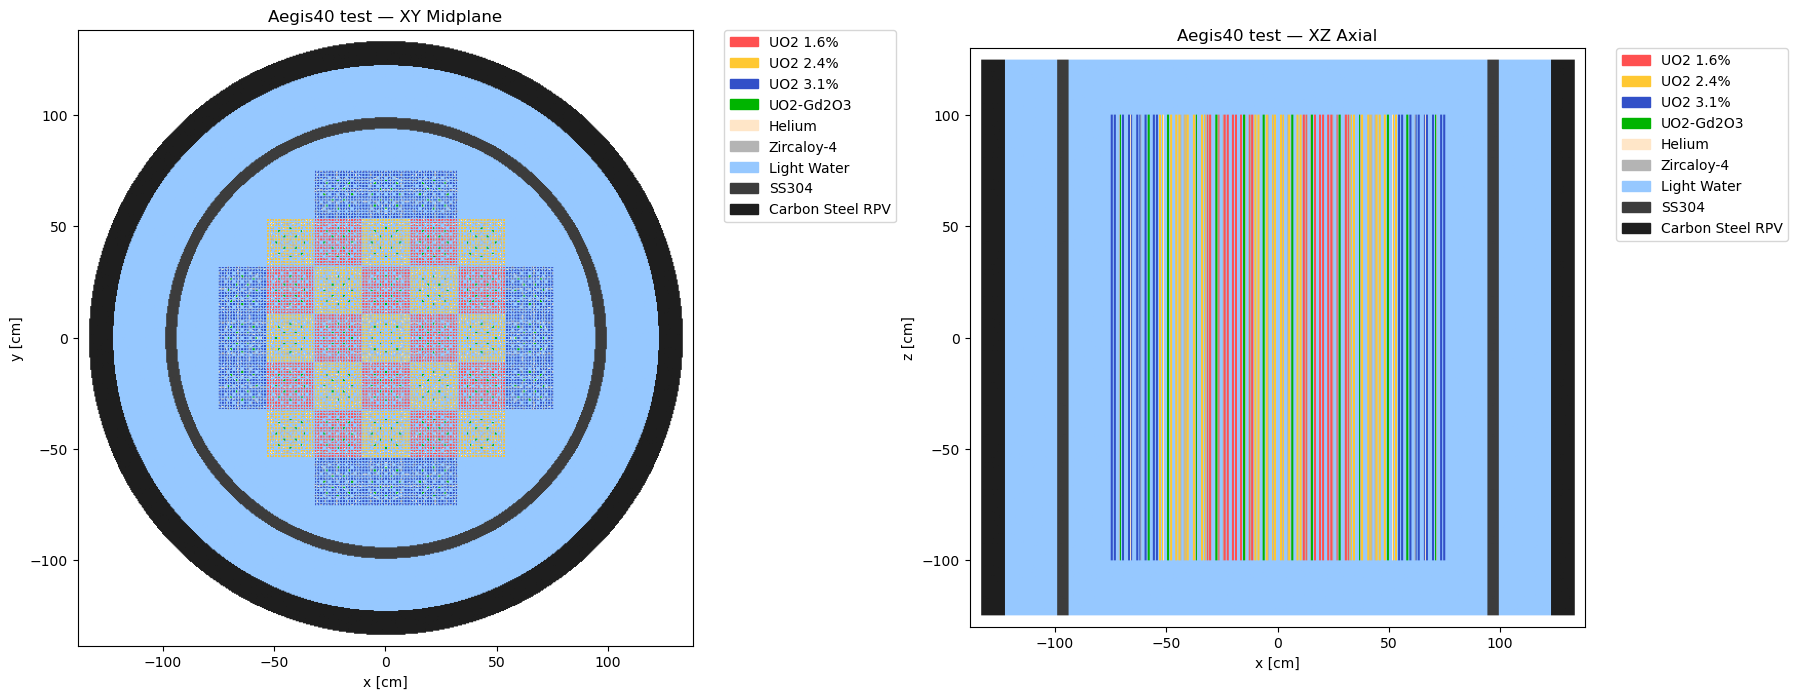

✓ Geometry verification plots generated


In [11]:
###############################################################################
#              6. GEOMETRY VERIFICATION — INLINE PLOTS
###############################################################################

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# XY slice at midplane
root.plot(
    basis='xy',
    origin=(0., 0., 0.),
    width=(2*rpv_OR + 10, 2*rpv_OR + 10),
    pixels=(600, 600),
    color_by='material',
    colors=color_map,
    axes=axes[0],
    legend=True
)
axes[0].set_title('Aegis40 test — XY Midplane')
axes[0].set_xlabel('x [cm]')
axes[0].set_ylabel('y [cm]')

# XZ axial slice
root.plot(
    basis='xz',
    origin=(0., 0., 0.),
    width=(2*rpv_OR + 10, z_upper_refl - z_lower_refl + 10),
    pixels=(600, 600),
    color_by='material',
    colors=color_map,
    axes=axes[1],
    legend=True
)
axes[1].set_title('Aegis40 test — XZ Axial')
axes[1].set_xlabel('x [cm]')
axes[1].set_ylabel('z [cm]')

plt.tight_layout()
plt.savefig('geometry_verification.png', dpi=150)
plt.show()
print("✓ Geometry verification plots generated")

In [12]:
###############################################################################
#                     7. RUN THE SIMULATION
###############################################################################
openmc.config["cross_sections"] = "/mnt/d/openmc_data/endfb-viii.0-hdf5/cross_sections.xml"
# Build the Model object (bundles geometry + materials + settings + tallies)
model = openmc.Model(geometry=geometry, materials=materials,
                     settings=settings, tallies=tallies)

# Run OpenMC
# NOTE: Uncomment the line below to execute the simulation.
# For a first run you may want to reduce particles/batches in the settings cell.
sp_filepath = model.run()

print(f"\n✓ Simulation complete — statepoint: {sp_filepath}")

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [13]:
###############################################################################
#          8a. POST-PROCESSING — k-effective & Flux Summary
###############################################################################
# NOTE: We extract data via tally .mean/.std_dev numpy arrays instead of
#       get_pandas_dataframe() to avoid the pandas StringArray compatibility
#       bug in this OpenMC version.

# Open the statepoint file
sp = openmc.StatePoint(sp_filepath)

# ── k-effective ──
keff = sp.keff
print("=" * 60)
print(f"  k-effective = {keff.n:.5f} ± {keff.s:.5f}")
print("=" * 60)

# ── Helper lists matching the filter bin order ──
fuel_mat_names = ['UO2 1.6%', 'UO2 2.4%', 'UO2 3.1%', 'UO2-Gd2O3']
e_lo = [1e-5, 0.625, 1.0e5]
e_hi = [0.625, 1.0e5, 20.0e6]
n_groups = len(e_lo)

# ── Energy-resolved fuel flux ──
t = sp.get_tally(name='Fuel flux (energy-resolved)')
flux_mean = t.mean.flatten()          # length = n_mats × n_groups
flux_std  = t.std_dev.flatten()

print("\n── Fuel Neutron Flux (by material & energy group) ──")
print(f"{'Material':<12} {'E_low [eV]':>12} {'E_high [eV]':>12} {'Mean':>14} {'Std Dev':>14}")
print("-" * 66)

# Store for plotting in the next cell
flux_data = {}
for i, mat in enumerate(fuel_mat_names):
    flux_data[mat] = {'mean': [], 'std': []}
    for j in range(n_groups):
        idx = i * n_groups + j
        flux_data[mat]['mean'].append(flux_mean[idx])
        flux_data[mat]['std'].append(flux_std[idx])
        print(f"{mat:<12} {e_lo[j]:>12.3e} {e_hi[j]:>12.3e} "
              f"{flux_mean[idx]:>14.6e} {flux_std[idx]:>14.6e}")

# ── Fission rates ──
t_fis = sp.get_tally(name='Fission rates')
score_names = ['fission', 'nu-fission', 'kappa-fission']
n_mats = len(fuel_mat_names)
n_scores = len(score_names)
fis_mean = t_fis.mean.reshape(n_mats, n_scores)
fis_std  = t_fis.std_dev.reshape(n_mats, n_scores)


print("\n── Fission Rates ──")
print(f"{'Material':<12} {'Score':<16} {'Mean':>14} {'Std Dev':>14}")
print("-" * 58)

fis_data = {}
for i, mat in enumerate(fuel_mat_names):
    for j, score in enumerate(score_names):
        fis_data[(mat, score)] = {'mean': fis_mean[i, j], 'std': fis_std[i, j]}
        print(f"{mat:<12} {score:<16} {fis_mean[i,j]:>14.6e} {fis_std[i,j]:>14.6e}")

# ── Heating in fuel ──
t_heat = sp.get_tally(name='Fuel heating')
heat_mean = t_heat.mean.flatten()
heat_std  = t_heat.std_dev.flatten()

print("\n── Fuel Heating (eV/source-particle) ──")
print(f"{'Material':<12} {'Mean':>14} {'Std Dev':>14}")
print("-" * 42)
for i, mat in enumerate(fuel_mat_names):
    print(f"{mat:<12} {heat_mean[i]:>14.6e} {heat_std[i]:>14.6e}")

# ── Power estimate ──
kf_total = sum(fis_data[(m, 'kappa-fission')]['mean'] for m in fuel_mat_names)
# Convert eV → Joules
eV_to_J = 1.60218e-19
# Power per source particle
power_per_source = kf_total * eV_to_J
print(f"\n── Total kappa-fission = {kf_total:.4e} eV/source")
print(f"   = {power_per_source:.4e} J/source")
print("\nNOTE:")
print("To convert to MWt, multiply by neutron source rate")
print("OpenMC eigenvalue runs are normalized per source particle")

  k-effective = 1.03362 ± 0.00089

── Fuel Neutron Flux (by material & energy group) ──
Material       E_low [eV]  E_high [eV]           Mean        Std Dev
------------------------------------------------------------------
UO2 1.6%        1.000e-05    6.250e-01   8.214161e-01   2.432443e-03
UO2 1.6%        6.250e-01    1.000e+05   1.561647e+00   3.235103e-03
UO2 1.6%        1.000e+05    2.000e+07   1.876190e+00   3.644726e-03
UO2 2.4%        1.000e-05    6.250e-01   7.521832e-01   1.960425e-03
UO2 2.4%        6.250e-01    1.000e+05   1.632277e+00   2.953183e-03
UO2 2.4%        1.000e+05    2.000e+07   2.078984e+00   3.998879e-03
UO2 3.1%        1.000e-05    6.250e-01   4.277384e-01   1.720066e-03
UO2 3.1%        6.250e-01    1.000e+05   1.011046e+00   3.339671e-03
UO2 3.1%        1.000e+05    2.000e+07   1.361968e+00   4.406708e-03
UO2-Gd2O3       1.000e-05    6.250e-01   1.744169e-02   1.028401e-04
UO2-Gd2O3       6.250e-01    1.000e+05   1.956457e-01   5.247123e-04
UO2-Gd2O3       1

/mnt/d/conda-envs/openmc-py311/lib/python3.11/site-packages/uncertainties/core.py:526: FutureWarning: Variable.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by Variable.error_components (with no parentheses).
  return float(sqrt(sum(delta**2 for delta in self.error_components().values())))
/mnt/d/conda-envs/openmc-py311/lib/python3.11/site-packages/uncertainties/core.py:491: FutureWarning: Variable.derivatives() is deprecated. It will be removed in a future release.
  for variable, derivative in self.derivatives.items():


In [14]:
print("=" * 70)
print("         Aegis-40 iPWR — OpenMC Simulation Summary")
print("=" * 70)

print(f"\n  k-effective        = {keff.n:.5f} ± {keff.s:.5f}")
print(f"  Batches            = {settings.batches} ({settings.inactive} inactive)")
print(f"  Particles          = {settings.particles:,}/batch")

# ── Total heating in fuel ──
total_fuel_heat = heat_mean.sum()
total_fuel_heat_std = np.sqrt((heat_std**2).sum())

print(f"\n  Fuel heating        = {total_fuel_heat:.4e} ± {total_fuel_heat_std:.2e} eV/src")

# ── Total kappa-fission ──
print(f"  Kappa-fission       = {kf_total:.4e} eV/src")

# ── Convert to physical power ──
eV_to_J = 1.60218e-19
H = kf_total * eV_to_J   # J/source

P_target = 125e6         # 125 MWth (≈40 MWe)

source_rate = P_target / H

print(f"\n  Energy/source       = {H:.4e} J/source")
print(f"  Target power        = {P_target/1e6:.1f} MWth")
print(f"  Neutron source      = {source_rate:.4e} n/s")

# ── nu-bar ──
nufis = sum(fis_data[(m, 'nu-fission')]['mean'] for m in fuel_mat_names)
fis   = sum(fis_data[(m, 'fission')]['mean'] for m in fuel_mat_names)

if fis > 0:
    nu_bar = nufis / fis
    print(f"\n  Average ν (nu-bar)  = {nu_bar:.4f}")

# ── Leakage (sanity check) ──
t_leak = sp.get_tally(name='Core barrel current')
leak_mean = t_leak.mean.flatten()[0]
leak_std  = t_leak.std_dev.flatten()[0]

print(f"  Leakage current     = {leak_mean:.4e} ± {leak_std:.2e}")

# ── Core description ──
print("\n  Reactor type        = Integral PWR (iPWR)")
print("  Core concept        = Soluble Boron Free (Gd₂O₃ burnable absorbers)")
print("  Electric output     = 40 MWe")
print("  Thermal power       = 125 MWth")
print("  Fuel assemblies     = 37 × 17×17")
print(f"  Active height       = {z_top - z_bot:.1f} cm")

print("=" * 70)

sp.close()

         Aegis-40 iPWR — OpenMC Simulation Summary

  k-effective        = 1.03362 ± 0.00089
  Batches            = 150 (50 inactive)
  Particles          = 10,000/batch

  Fuel heating        = 7.4184e+07 ± 1.23e+05 eV/src
  Kappa-fission       = 8.1612e+07 eV/src

  Energy/source       = 1.3076e-11 J/source
  Target power        = 125.0 MWth
  Neutron source      = 9.5597e+18 n/s

  Average ν (nu-bar)  = 2.4520
  Leakage current     = 1.2734e-02 ± 1.17e-04

  Reactor type        = Integral PWR (iPWR)
  Core concept        = Soluble Boron Free (Gd₂O₃ burnable absorbers)
  Electric output     = 40 MWe
  Thermal power       = 125 MWth
  Fuel assemblies     = 37 × 17×17
  Active height       = 200.0 cm


In [15]:
sp = openmc.StatePoint('statepoint.150.h5')

# --- Fuel heating ---
t_heat_fuel = sp.get_tally(name='Fuel heating')
E_fuel_eV   = t_heat_fuel.mean.ravel()

# --- Total heating (best normalization) ---
t_heat_all = sp.get_tally(name='Total heating')
E_tot_eV   = t_heat_all.mean.sum()

# --- Convert to Joules ---
eV_to_J = 1.60218e-19
E_tot_J = E_tot_eV * eV_to_J

# --- Aegis-40 power ---
P_target = 125e6   # 125 MWth (40 MWe)

# --- Source rate ---
source_rate = P_target / E_tot_J

print("\n=== Aegis-40 Power Normalization ===")
print(f"Energy per source = {E_tot_J:.4e} J/source")
print(f"Target power      = {P_target/1e6:.1f} MWth")
print(f"Source rate       = {source_rate:.4e} n/s")

# --- Power per material ---
P_fuel_W = E_fuel_eV * eV_to_J * source_rate

labels = ['UO2 1.6%', 'UO2 2.4%', 'UO2 3.1%', 'UO2-Gd2O3']

print("\n=== Fuel Power Distribution ===")
for lab, P in zip(labels, P_fuel_W):
    print(f"{lab:<12}: {P/1e6:.2f} MW")

print(f"\nTotal fuel power = {P_fuel_W.sum()/1e6:.2f} MW")

sp.close()


=== Aegis-40 Power Normalization ===
Energy per source = 1.2121e-11 J/source
Target power      = 125.0 MWth
Source rate       = 1.0313e+19 n/s

=== Fuel Power Distribution ===
UO2 1.6%    : 36.34 MW
UO2 2.4%    : 48.93 MW
UO2 3.1%    : 35.62 MW
UO2-Gd2O3   : 1.68 MW

Total fuel power = 122.58 MW


In [16]:
sp = openmc.StatePoint('statepoint.150.h5')

# --- list tallies ---
print("Available tallies:")
for t in sp.tallies.values():
    print("  •", t.name)

# --- get XY tally ---
t_xy = sp.get_tally(name='Mesh flux XY')

# --- extract mesh safely ---
mesh = t_xy.filters[0].mesh
nx, ny, nz = mesh.dimension
n_scores = len(t_xy.scores)

flux_xy = t_xy.mean.reshape((nx, ny, nz, n_scores))
flux_xy = flux_xy.squeeze(axis=2)

flux_map = flux_xy[:, :, 0]

Available tallies:
  • Fuel flux (energy-resolved)
  • Fission rates
  • Fuel heating
  • Total heating
  • Absorption & scattering
  • Mesh flux XY
  • Mesh flux XZ
  • Core barrel current
  • Core flux


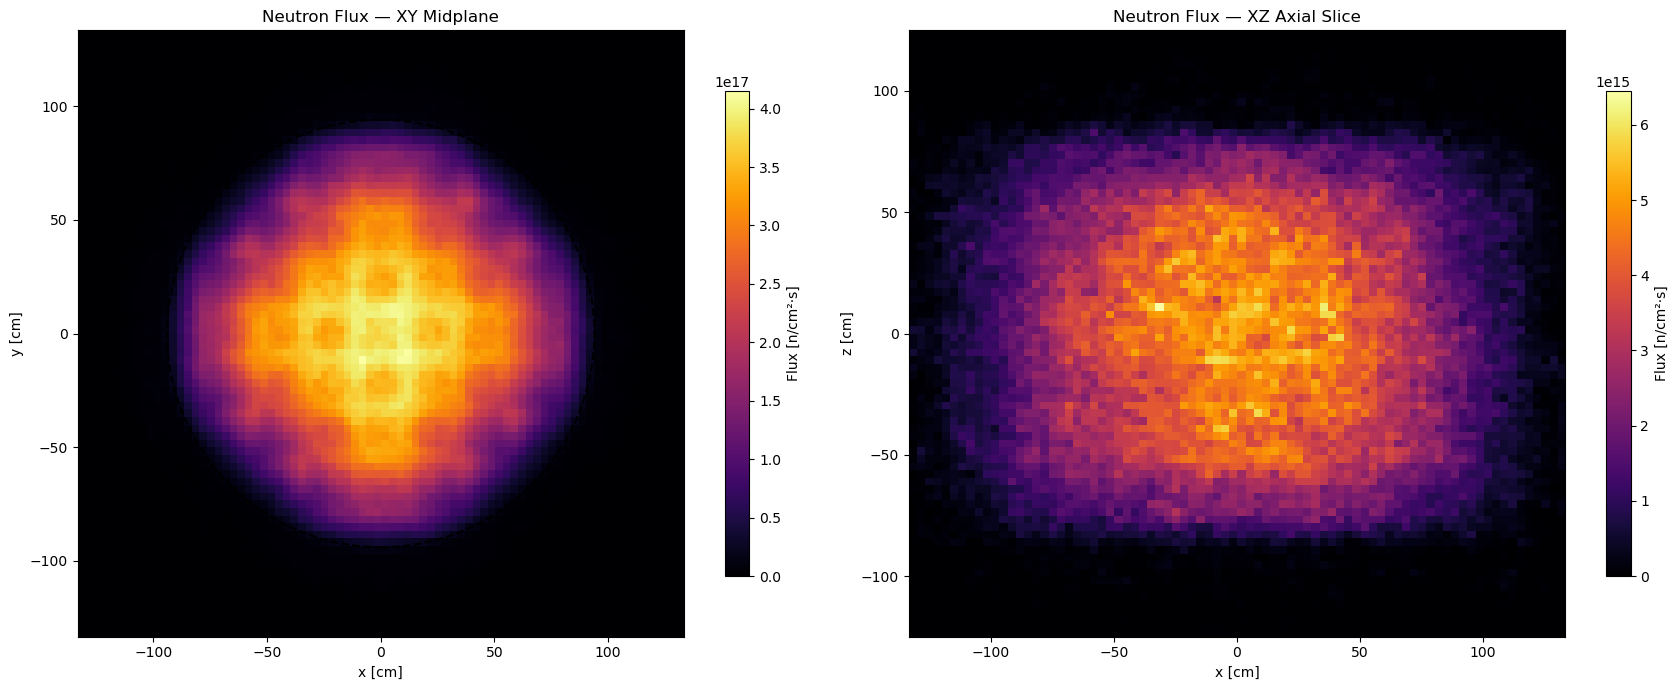

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- XY flux ---
t_xy = sp.get_tally(name='Mesh flux XY')

nx, ny, nz = mesh_xy.dimension
n_scores_xy = len(t_xy.scores)

flux_xy = t_xy.mean.reshape((nx, ny, nz, n_scores_xy))
flux_xy = flux_xy.squeeze(axis=2)

flux_map = flux_xy[:, :, 0]

# --- Convert to physical units ---
flux_map = flux_map * source_rate

extent_xy = [-rpv_OR, rpv_OR, -rpv_OR, rpv_OR]

im1 = axes[0].imshow(
    flux_map,
    origin='lower',
    extent=extent_xy,
    cmap='inferno',
    aspect='equal')

axes[0].set_title('Neutron Flux — XY Midplane')
axes[0].set_xlabel('x [cm]')
axes[0].set_ylabel('y [cm]')

fig.colorbar(im1, ax=axes[0],
             label='Flux [n/cm²·s]', shrink=0.8)

# --- Barrel & RPV ---
for r, ls in [(core_barrel_IR, '--'),
              (rpv_IR, '-.')]:
    axes[0].add_patch(
        plt.Circle((0,0), r,
                   fill=False, color='black',
                   linestyle=ls, linewidth=1.5))

# --- XZ flux ---
t_xz = sp.get_tally(name='Mesh flux XZ')

nx2, ny2, nz2 = mesh_xz.dimension
flux_xz = t_xz.mean.reshape((nx2, ny2, nz2))
flux_xz = flux_xz.squeeze(axis=1)

flux_xz = flux_xz * source_rate

extent_xz = [-rpv_OR, rpv_OR, z_lower_refl, z_upper_refl]

im2 = axes[1].imshow(
    flux_xz.T,
    origin='lower',
    extent=extent_xz,
    cmap='inferno',
    aspect='auto')

axes[1].set_title('Neutron Flux — XZ Axial Slice')
axes[1].set_xlabel('x [cm]')
axes[1].set_ylabel('z [cm]')

fig.colorbar(im2, ax=axes[1],
             label='Flux [n/cm²·s]', shrink=0.8)

# --- Active fuel bounds ---
for z_line in [z_bot, z_top]:
    axes[1].axhline(z_line, color='black',
                    linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('aegis40_flux_maps.png', dpi=200)
plt.show()